# 📝 Instrucciones

**Prediciendo la diabetes**

Este conjunto de datos proviene originalmente del Instituto Nacional de Diabetes y Enfermedades Digestivas y Renales. El objetivo es predecir en base a medidas diagnósticas si un paciente tiene o no diabetes.

## Paso 1: Carga del conjunto de datos

El conjunto de datos se puede encontrar en esta carpeta de proyecto bajo el nombre diabetes.csv. 

| Variable                 | Descripción                                                                    | Tipo             |
| ------------------------ | ------------------------------------------------------------------------------ | ---------------- |
| Pregnancies              | Número de embarazos del paciente                                               | Numérico         |
| Glucose                  | Concentración de glucosa en plasma a las 2 horas de un test de tolerancia oral | Numérico         |
| BloodPressure            | Presión arterial diastólica (mm Hg)                                            | Numérico         |
| SkinThickness            | Grosor del pliegue cutáneo del tríceps (mm)                                    | Numérico         |
| Insulin                  | Insulina sérica de 2 horas (mu U/ml)                                           | Numérico         |
| BMI                      | Índice de masa corporal                                                        | Numérico         |
| DiabetesPedigreeFunction | Función de pedigrí de diabetes                                                 | Numérico         |
| Age                      | Edad del paciente                                                              | Numérico         |
| Outcome                  | Resultado: 0 = no diabetes, 1 = diabetes                                       | Numérico (clase) |


**Cargamos el dataset**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
df = pd.read_csv("../data/raw/diabetes.csv")

### Paso 2. EDA

In [15]:
#Tamaño del dataset
print(f"El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas.")

El dataset tiene 768 filas y 9 columnas.


In [16]:
# Primeras filas del dataset
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [17]:
#Información de las columnas
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [18]:
#No hay datos nulos. Ahora miramos el tipo de datos:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

**Dataset con un número de variables manejable. Todas numéricas y sin datos nulos.**

**Outcome es la variable objetivo. Variable binaria.**
| Variable                 | Tipo    | Observaciones                         |
| ------------------------ | ------- | ------------------------------------- |
| Pregnancies              | int64   | Número de embarazos                   |
| Glucose                  | int64   | Concentración de glucosa              |
| BloodPressure            | int64   | Presión arterial diastólica           |
| SkinThickness            | int64   | Grosor del pliegue cutáneo            |
| Insulin                  | int64   | Insulina sérica                       |
| BMI                      | float64 | Índice de masa corporal               |
| DiabetesPedigreeFunction | float64 | Función de pedigrí de diabetes        |
| Age                      | int64   | Edad del paciente                     |
| Outcome                  | int64   | Target: 0 = no diabetes, 1 = diabetes |


In [19]:
#Buscamos valores faltantes representados por ceros
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [21]:
#Posibles valores duplicados:
df.duplicated().sum()

np.int64(0)

### Miramos Estadística Descriptiva

In [23]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


**En término generales las variables aparentan tener distribuciones normales, excepto por la insulina que la mediana está muy por debajo de la media y los valores máximos demasiado elevados, lo que refleja una distribución fuertemente sesgada a la derecha con muchos valores ceros y valores muy altos (outliers seguramente)**

### Pasamos al estudio de la variable objetivo

In [25]:
#Conteo de clases
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

Text(0.5, 0, 'Outcome')

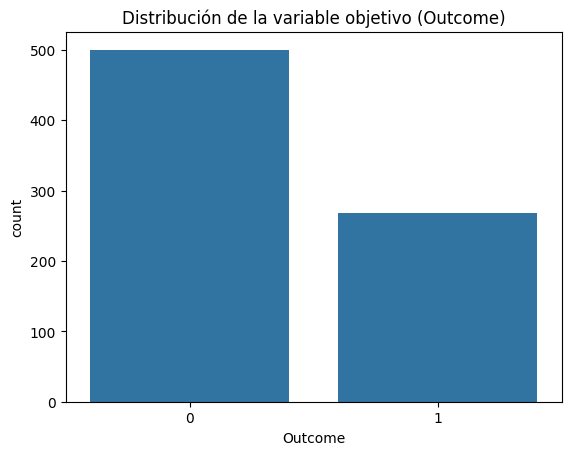

In [26]:
#Visualizamos la distribución de la variable objetivo
sns.countplot(x="Outcome", data=df)
plt.title("Distribución de la variable objetivo (Outcome)")
plt.xlabel("Outcome")

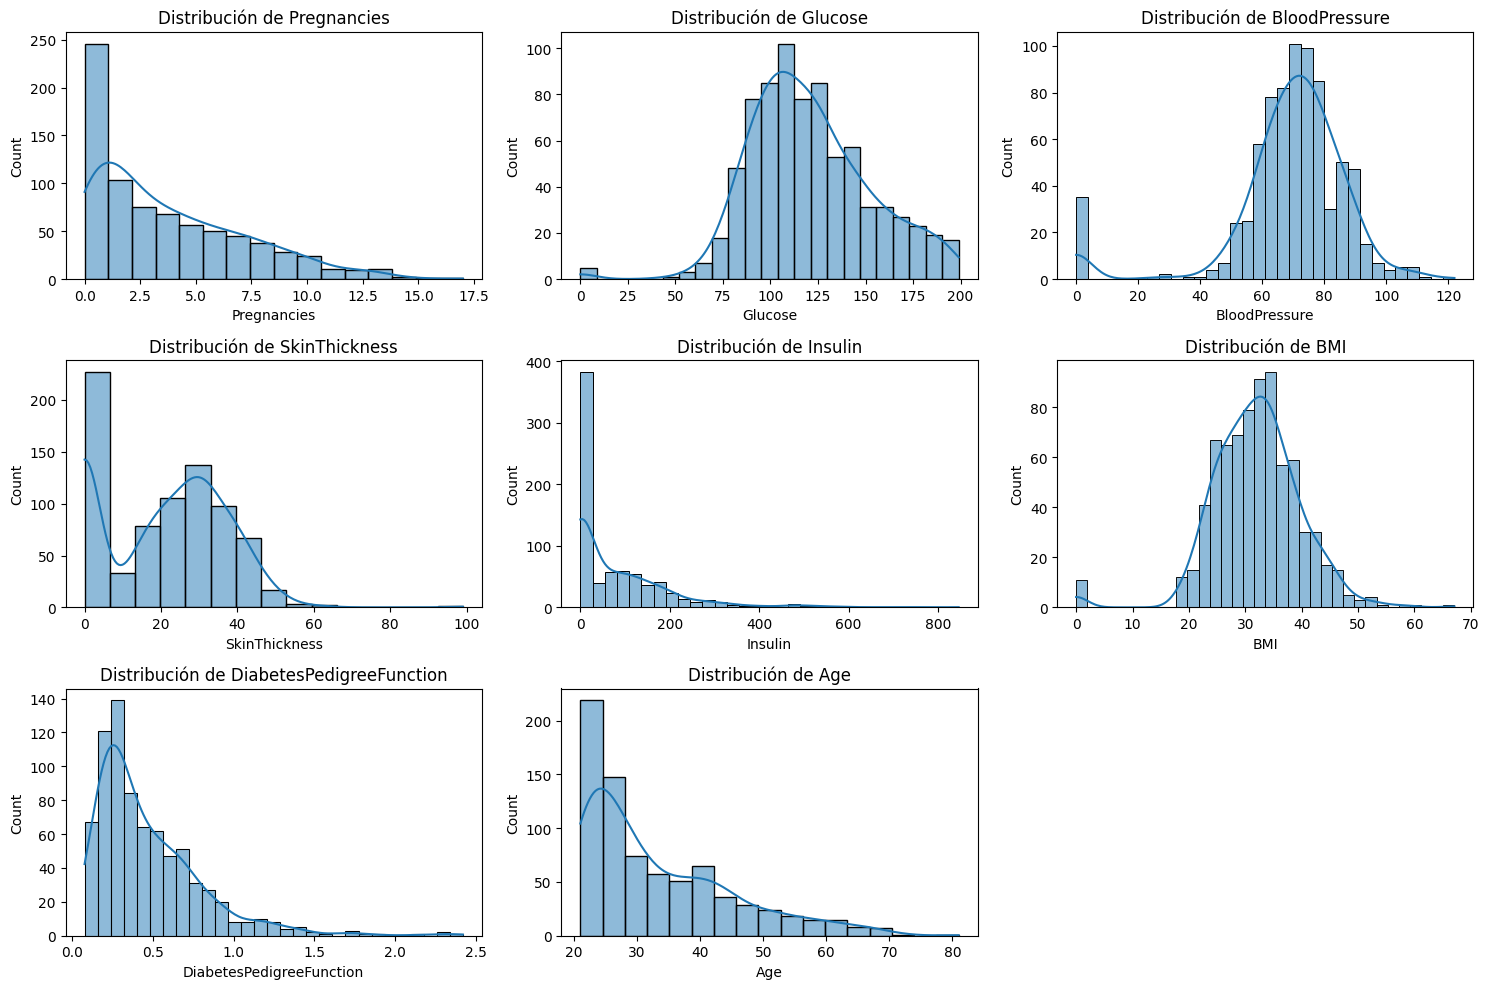

In [31]:
#Análisis univariado de las características numéricas
#Histogramas para cada característica numérica
num_cols = df.drop("Outcome", axis=1).select_dtypes(include=np.number).columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribución de {col}")
plt.tight_layout()
plt.show()

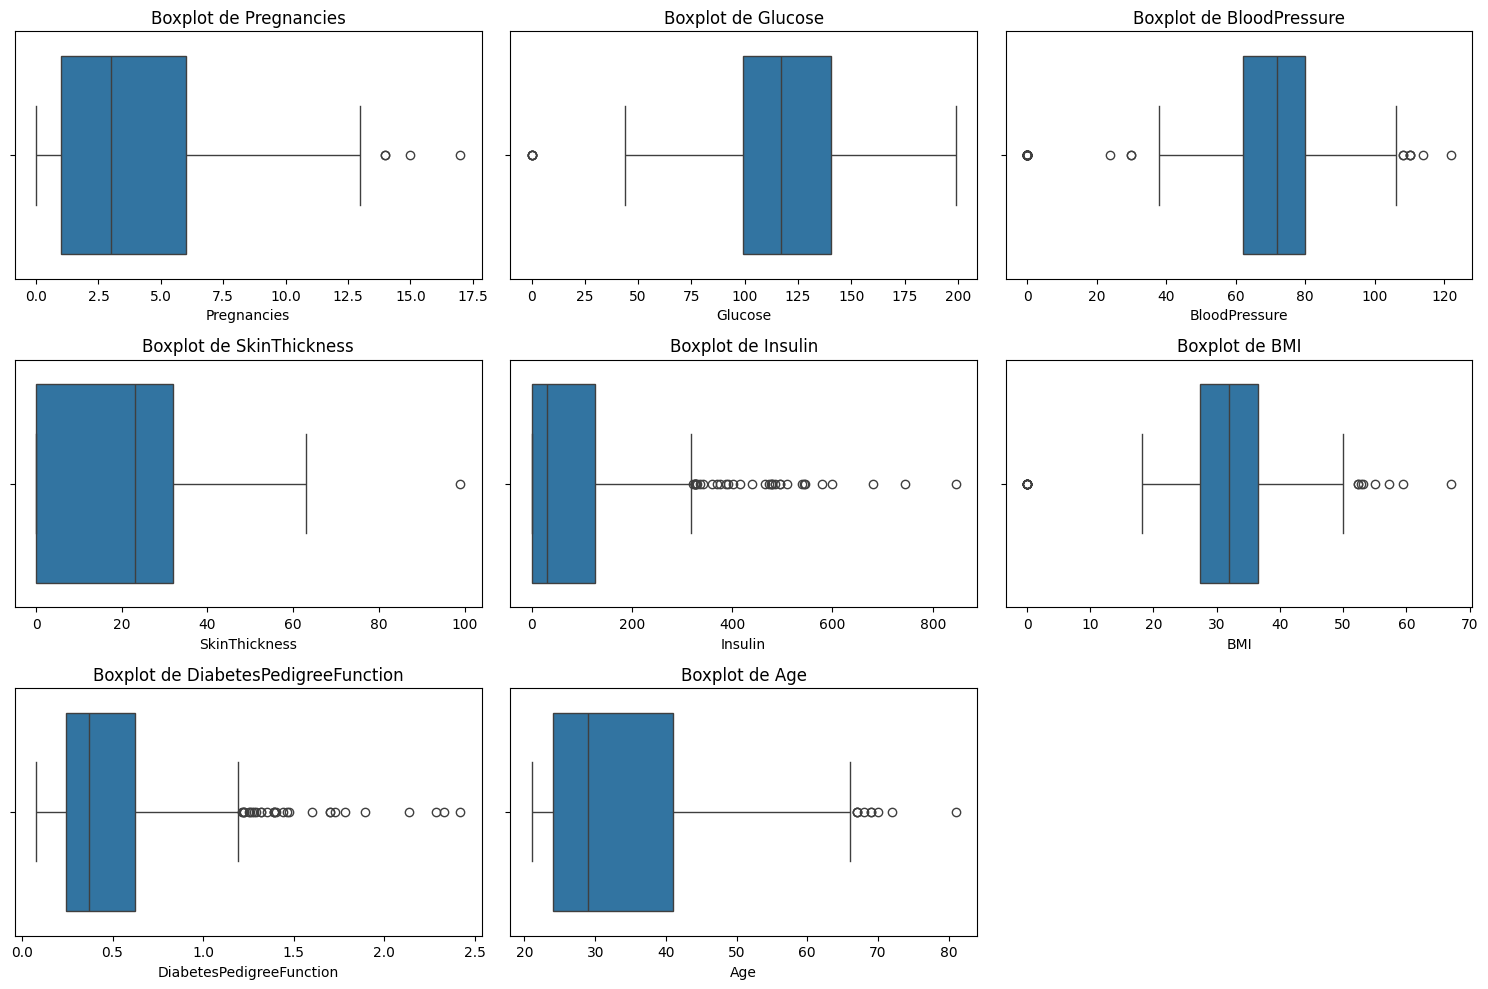

In [30]:
#Boxplots para cada característica numérica
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col}")
plt.tight_layout()
plt.show()

**Se observan muchos ceros que podrían meter ruido a los modelos**

In [34]:
#Resumen de ceros sospechosos
zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
for col in zero_cols:
    zero_count = (df[col] == 0).sum()
    print(f"{col}: {zero_count} ceros")
    print(f"{col}: {zero_count / len(df) * 100:.2f}% de ceros")

Glucose: 5 ceros
Glucose: 0.65% de ceros
BloodPressure: 35 ceros
BloodPressure: 4.56% de ceros
SkinThickness: 227 ceros
SkinThickness: 29.56% de ceros
Insulin: 374 ceros
Insulin: 48.70% de ceros
BMI: 11 ceros
BMI: 1.43% de ceros


**Hay mucha proporción de ceros en variables como SkinThickness e Insulin. Por ahora lo dejaremos en el modelo y si causaran ruido se corregirá en la optimización**

Por ahora continuamos con el análisis de correlaciones

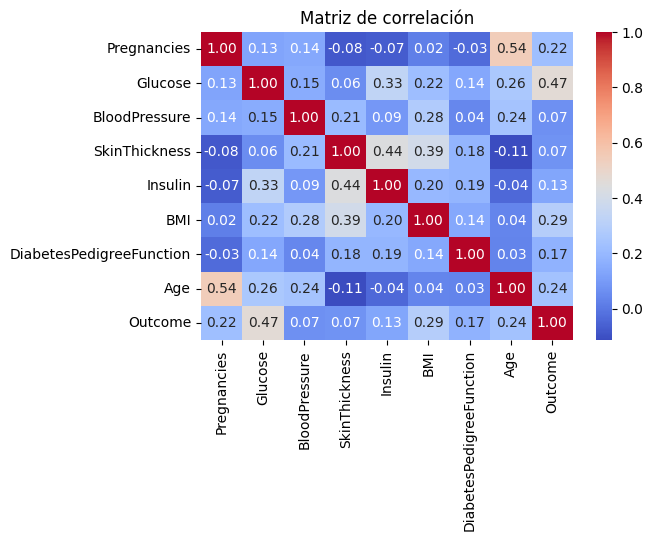

In [38]:
#Matriz de correlación
corr = df.corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

In [37]:
#Correlación entre características numéricas y la variable objetivo
print("Correlación de características con Outcome:")
print(df.corr()["Outcome"].sort_values(ascending=False))

Correlación de características con Outcome:
Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64


1. Razonablemente la variable más fuerte es el nivel de glucosa. Niveles más altos se asocian a mayor probabilidad de diabetes
2. El Índice de Masa Corporal se relaciona con mayor riesgo de diabetes
3. La edad avanzada se asocia a mayor riesgo
4. Nivel de insulina, SkinThickness y Presión Sanguínea aparentemente baja correlación. **Probablemente afectados por los valores con ceros**

**Por ahora dejaremos los outliers en el modelo y si fuera necesario se tratarán en la etapa de optimización**

## Paso 3. Modelo de árbol de decisión

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay

In [42]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [43]:
#Árbol clásico con criterio de gini
tree_gini = DecisionTreeClassifier(criterion="gini", random_state=42)
tree_gini.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [44]:
#Predicciones y evaluación
y_pred_gini = tree_gini.predict(X_test)
print("Reporte de clasificación (Gini):")
print(classification_report(y_test, y_pred_gini))

Reporte de clasificación (Gini):
              precision    recall  f1-score   support

           0       0.76      0.85      0.80       100
           1       0.64      0.50      0.56        54

    accuracy                           0.73       154
   macro avg       0.70      0.68      0.68       154
weighted avg       0.72      0.73      0.72       154



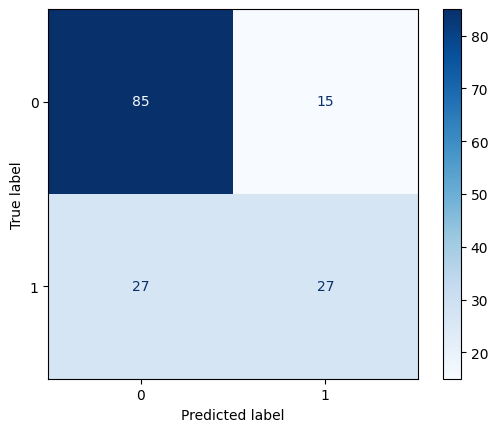

In [ ]:
#Matriz de confusión
cm_gini = confusion_matrix(y_test, y_pred_gini)
ConfusionMatrixDisplay(cm_gini, display_labels=tree_gini.classes_).plot(cmap="Blues")

## Interpretación:

1. Verdaderos negativos: 85 casos bien clasificados sin diabetes
2. Verdaderos positivos: 27 casos bien clasificados con diabetes
3. Falsos positivos: 15 casos detectados como diabetes sin ser diabetes
4. Falsos negativos: 27 casos de no detectar diabetes cuando no hay

Este modelo de árbol de decisión obtuvo un accuracy de 73% mostrando un buen rendimiento en la clase de "no diabetes" pero con baja capacidad de detectar los casos positivos (recall del 50%). Médicamente es un problema porque el modelo tiene problemas para identificar pacientes con diabetes, observado en un número considerable de falsos negativos, lo cual es crítico en este tipo de problemas.